<a href="https://colab.research.google.com/github/2023006766/deep-learning/blob/main/and_gate_with_trained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial weights:
[[-0.42009322]
 [-0.80434244]]
Initial bias: -0.5496751588473252

--- Training single perceptron (AND Gate) ---
Iteration    0: Loss = 0.425262
Iteration  100: Loss = 0.419600
Iteration  200: Loss = 0.414929
Iteration  300: Loss = 0.411036
Iteration  400: Loss = 0.407705
Iteration  500: Loss = 0.404712
Iteration  600: Loss = 0.401822
Iteration  700: Loss = 0.398805
Iteration  800: Loss = 0.395460
Iteration  900: Loss = 0.391644
Iteration 1000: Loss = 0.387299
Iteration 1100: Loss = 0.382443
Iteration 1200: Loss = 0.377156
Iteration 1300: Loss = 0.371551
Iteration 1400: Loss = 0.365745
Iteration 1500: Loss = 0.359846
Iteration 1600: Loss = 0.353942
Iteration 1700: Loss = 0.348102
Iteration 1800: Loss = 0.342372
Iteration 1900: Loss = 0.336786
Iteration 2000: Loss = 0.331363
Iteration 2100: Loss = 0.326114
Iteration 2200: Loss = 0.321043
Iteration 2300: Loss = 0.316148
Iteration 2400: Loss = 0.311428
Iteration 2500: Loss = 0.306877
Iteration 2600: Loss = 0.302489
Iterati

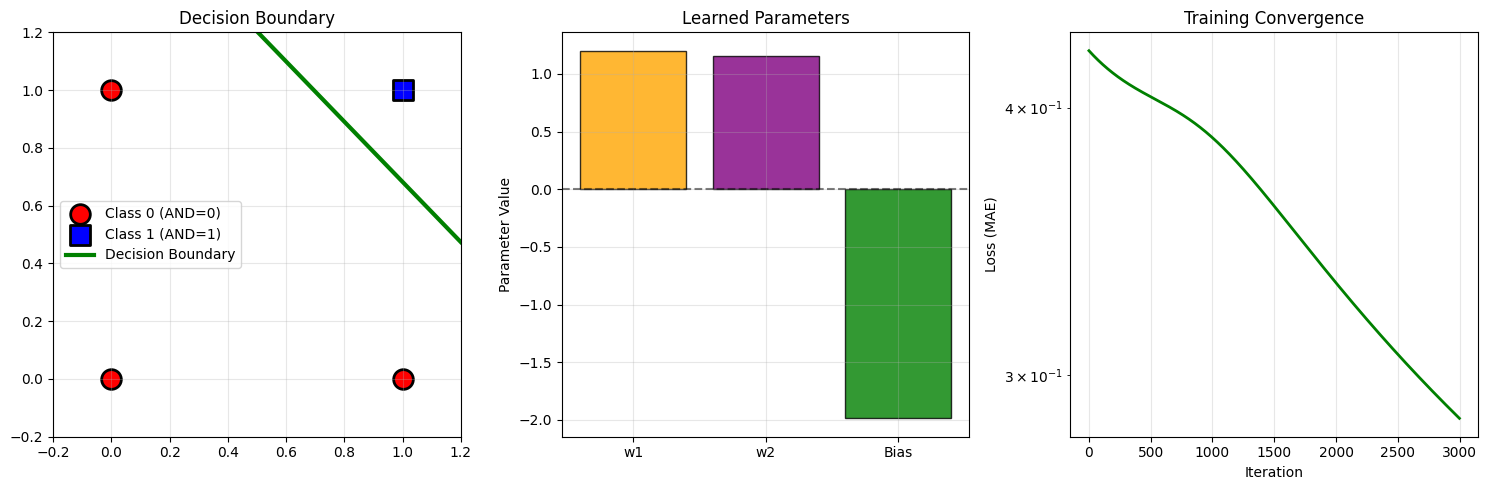


DECISION BOUNDARY VERIFICATION:
Equation: 1.201x + 1.152y + -1.987 = 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initializing parameters
input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 100

# Training data (AND Gate)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [1]])

# Initializing weights and bias
weights = np.random.uniform(-1, 1, (input_size, 1))
bias = np.random.uniform(-1, 1, (1, 1))

print(f"Initial weights:\n{weights}")
print(f"Initial bias: {bias[0,0]}")

# Activation functions
def sigmoid(x):
    # Clipping to avoid overflow in exp
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

def predict(x, weights, bias):
    linear = np.dot(x, weights) + bias
    return sigmoid(linear)

print("\n--- Training single perceptron (AND Gate) ---")
loss_history = []

for iteration in range(iterations):
    # Forward propagation
    output = predict(X, weights, bias)

    # Error calculation
    error = y - output

    # Backpropagation (Gradient Descent)
    adjustment = error * sigmoid_derivative(output)
    weights += learning_rate * np.dot(X.T, adjustment)
    bias += learning_rate * np.sum(adjustment, axis=0, keepdims=True)

    current_loss = np.mean(np.abs(error))
    loss_history.append(current_loss)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration:4d}: Loss = {current_loss:.6f}")

print("\nTraining complete!")
print(f"Final weights: w1 = {weights[0][0]:.3f}, w2 = {weights[1][0]:.3f}")
print(f"Final Bias: {bias[0][0]:.3f}")

# Final Predictions
final_predictions = predict(X, weights, bias)
print("\nPredictions (AND Gate):")
for i in range(len(X)):
    pred_class = 1 if final_predictions[i][0] > 0.5 else 0
    print(f"Input: [{X[i][0]}, {X[i][1]}] -> Pred: {final_predictions[i][0]:.4f} (Class {pred_class})")

# --- Visualization ---
plt.figure(figsize=(15, 5))

# 1. Decision Boundary Plot
plt.subplot(1, 3, 1)
# Plotting class 0
plt.scatter(X[(y.flatten() == 0), 0], X[(y.flatten() == 0), 1],
            s=200, c='red', marker='o', edgecolors='black', linewidth=2, label='Class 0 (AND=0)')
# Plotting class 1
plt.scatter(X[(y.flatten() == 1), 0], X[(y.flatten() == 1), 1],
            s=200, c='blue', marker='s', edgecolors='black', linewidth=2, label='Class 1 (AND=1)')

w1, w2 = weights[0, 0], weights[1, 0]
b = bias[0, 0]

boundary_x = np.linspace(-0.2, 1.2, 100)
if abs(w2) > 1e-6:
    boundary_y = (-w1 * boundary_x - b) / w2
    plt.plot(boundary_x, boundary_y, 'g-', linewidth=3, label='Decision Boundary')
else:
    # Vertical line case
    plt.axvline(x=-b/w1, color='g', linewidth=3, label='Decision Boundary')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.title("Decision Boundary")
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Learned Parameters Bar Chart
plt.subplot(1, 3, 2)
params = ['w1', 'w2', 'Bias']
values = [weights[0, 0], weights[1, 0], bias[0, 0]]
plt.bar(params, values, color=['orange', 'purple', 'green'], alpha=0.8, edgecolor='black')
plt.ylabel('Parameter Value')
plt.title('Learned Parameters')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# 3. Training Convergence (Loss)
plt.subplot(1, 3, 3)
plt.semilogy(loss_history, 'g-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss (MAE)')
plt.title('Training Convergence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final Verification Math
print("\nDECISION BOUNDARY VERIFICATION:")
print(f"Equation: {weights[0,0]:.3f}x + {weights[1,0]:.3f}y + {bias[0,0]:.3f} = 0")